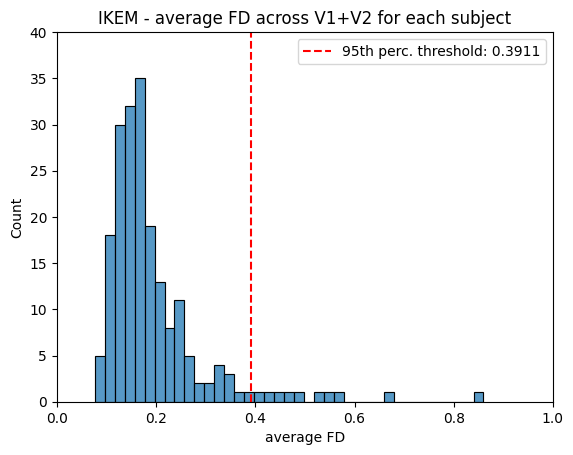

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
from pathlib import Path
import yaml
import seaborn as sns

site_name = 'ikem'
run = 'resting'

config_file = Path(f"../../data/{site_name}/config.yaml")
    
with open(config_file, 'r') as file:
    config = yaml.safe_load(file)

run_variants = config['runs'].get(run, [])

root_dir = Path('/hydra/hydra_io/vypocty/tomecek/cpca/data').joinpath(site_name)

try:
    df_fd = pd.read_csv(root_dir.joinpath(run, f"eso_{run}_fd_motion_{site_name}.csv"))
except FileNotFoundError:
    raise FileNotFoundError(f"Could not find the FD motion file at: {root_dir.joinpath(run, f'eso_{run}_fd_motion_{site_name}.csv')}")
    
# Aggregate FD from the two sessions
agg_fd = df_fd.loc[:, ['meanFD_V1', 'meanFD_V2']].mean(axis=1)

# Set the threshold
fd_thr = np.percentile(agg_fd, 95)

plt.figure()
sns.histplot(agg_fd, bins=30, binwidth=0.02)
plt.axvline(fd_thr, color='red', linestyle='--', label=f'95th perc. threshold: {fd_thr:.4f}')
plt.xlabel('average FD')
plt.xlim((0, 1))
plt.ylim((0, 40))
plt.title(f"{site_name.upper()} - average FD across V1+V2 for each subject")
plt.legend()
plt.savefig(root_dir.joinpath(run, f'eso_{run}_aggregated_fd_motion_{site_name}.png'))
plt.show()
